<a href="https://colab.research.google.com/github/HariganeshV/Brain-Tumor-Detection/blob/main/VELAMMAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


DATASET UPLOAD

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/BrainTumorDataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_1389.jpg  
  inflating: Training/glioma/Tr-gl_139.jpg  
  inflating: Training/glioma/Tr-gl_1390.jpg  
  inflating: Training/glioma/Tr-gl_1391.jpg  
  inflating: Training/glioma/Tr-gl_1392.jpg  
  inflating: Training/glioma/Tr-gl_1393.jpg  
  inflating: Training/glioma/Tr-gl_1394.jpg  
  inflating: Training/glioma/Tr-gl_1395.jpg  
  inflating: Training/glioma/Tr-gl_1396.jpg  
  inflating: Training/glioma/Tr-gl_1397.jpg  
  inflating: Training/glioma/Tr-gl_1398.jpg  
  inflating: Training/glioma/Tr-gl_1399.jpg  
  inflating: Training/glioma/Tr-gl_14.jpg  
  inflating: Training/glioma/Tr-gl_140.jpg  
  inflating: Training/glioma/Tr-gl_1400.jpg  
  inflating: Training/glioma/Tr-gl_141.jpg  
  inflating: Training/glioma/Tr-gl_142.jpg  
  inflating: Training/glioma/Tr-gl_143.jpg  
  inflating: Training/glioma/Tr-gl_144.jpg  
  inflating: Training/glioma/Tr-gl_145.jpg  
  inflating: Training/glioma/Tr-gl_146

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['IMG-20240725-WA0012.jpg', 'Classroom', 'STUDENT PERSONAL DETAILS.docx', 'IMG-20240823-WA0002.jpg', 'Screenshot_2024_0918_124219.jpg', 'Untitled spreadsheet (1).gsheet', 'Untitled spreadsheet.gsheet', 'Beee presentation video.html', 'VID-20241105-WA0000 (2).mp4', 'HG C PROGRAM CA3 ASSIGNMENT.pdf', 'BEEE PRESENTATION E0524007.mp4', 'VID-20241105-WA0000 (1).mp4', 'VID-20241105-WA0000.mp4', 'Hariganesh - DS test (1).pdf', 'Hariganesh - DS test.pdf', 'maths assignment.pdf', 'LibraryManagementReport(14) (2).pdf', 'LibraryManagementReport(14) (1).pdf', 'LibraryManagementReport(14).pdf', 'Offer Letter Acceptance.pdf', 'WhatsApp Image 2025-06-17 at 6.39.46 PM.jpeg', 'Hariganesh V.jpeg', 'Colab Notebooks', 'MED23CL202 Python Laboratory ', 'Market Research on Meesho.pptx', 'Document from Hariganesh.pdf', 'PCP Abstract.pdf', 'HG Maths 4 (Assignment 3).pdf', 'Experiment 5 Web technology ', 'Web technology exp 4', '1771563600643.jpg', 'Cell biology class test-1.pdf', 'BrainTumorDataset.zip', 'Test

In [ ]:
train_path = "/content/drive/MyDrive/Training"
test_path = "/content/drive/MyDrive/Testing"

In [ ]:
import os

print("Training classes:", os.listdir(train_path))
print("Testing classes:", os.listdir(test_path))

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Create Data Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 0 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


Check Training Folder Structure

In [ ]:
import os

for folder in os.listdir(train_path):
    print(folder, ":", len(os.listdir(train_path+"/"+folder)))

glioma : 0
meningioma : 0
notumor : 0
pituitary : 0


Inspect Actual Structure

In [ ]:
import os

for root, dirs, files in os.walk(train_path):
    print(root, "->", len(files), "files")

/content/drive/MyDrive/Training -> 0 files
/content/drive/MyDrive/Training/glioma -> 0 files
/content/drive/MyDrive/Training/meningioma -> 0 files
/content/drive/MyDrive/Training/notumor -> 0 files
/content/drive/MyDrive/Training/pituitary -> 0 files


RE UNZIPPING

In [ ]:
!unzip -o "/content/drive/MyDrive/BrainTumorDataset.zip" -d "/content/drive/MyDrive/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1386.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1387.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1388.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1389.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_139.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1390.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1391.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1392.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1393.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1394.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1395.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1396.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/Tr-gl_1397.jpg  
  inflating: /content/drive/MyDrive/Training/glioma/T

In [ ]:
import os

train_path = "/content/drive/MyDrive/Training"

for root, dirs, files in os.walk(train_path):
    print(root, "->", len(files), "files")

/content/drive/MyDrive/Training -> 0 files
/content/drive/MyDrive/Training/glioma -> 1400 files
/content/drive/MyDrive/Training/meningioma -> 1386 files
/content/drive/MyDrive/Training/notumor -> 1282 files
/content/drive/MyDrive/Training/pituitary -> 1362 files


In [ ]:
import os

train_path = "/content/drive/MyDrive/Testing"

for root, dirs, files in os.walk(train_path):
    print(root, "->", len(files), "files")

/content/drive/MyDrive/Testing -> 0 files
/content/drive/MyDrive/Testing/glioma -> 400 files
/content/drive/MyDrive/Testing/meningioma -> 400 files
/content/drive/MyDrive/Testing/notumor -> 400 files
/content/drive/MyDrive/Testing/pituitary -> 400 files


Reload Data Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


Build VGG16 Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,596 (68.38 MB)

 Trainable params: 3,211,908 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 397ms/step - accuracy: 0.4034 - loss: 2.3619 - val_accuracy: 0.7650 - val_loss: 0.6677
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - accuracy: 0.6153 - loss: 0.8316 - val_accuracy: 0.8219 - val_loss: 0.5517
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.6628 - loss: 0.7479 - val_accuracy: 0.8731 - val_loss: 0.4775
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.7048 - loss: 0.6914 - val_accuracy: 0.8656 - val_loss: 0.4066
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 353ms/step - accuracy: 0.6985 - loss: 0.6672 - val_accuracy: 0.9112 - val_loss: 0.3383
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 355ms/step - accuracy: 0.7281 - loss: 0.6071 - val_accuracy: 0.9287 - val_loss: 0.2844
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 354ms/step - accuracy: 0.7469 - loss: 0.5642 - val_accuracy: 0.9394 - val_loss: 0.2445
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 392ms/step - accuracy: 0.7660 - loss: 0.5038 - val_accu

Plot Accuracy Graph

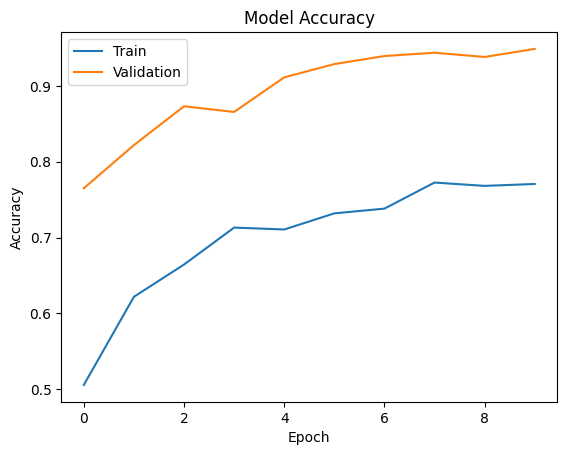

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

Loss Graph

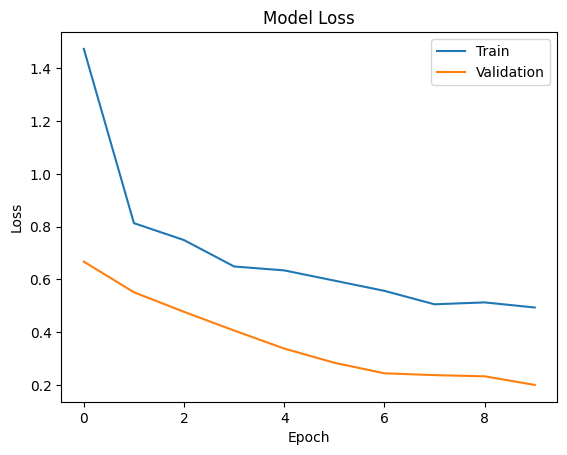

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

Confusion Matrix FOR Multi-class (WEAK)

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step


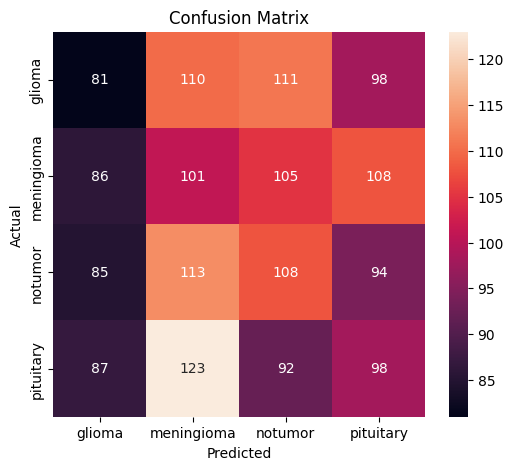

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# predictions
predictions = model.predict(test_data)
pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

# confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
for layer in base_model.layers[-8:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 447ms/step - accuracy: 0.2962 - loss: 13.4148 - val_accuracy: 0.2500 - val_loss: 1.3881
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - accuracy: 0.2650 - loss: 1.4315 - val_accuracy: 0.2769 - val_loss: 1.3875
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 420ms/step - accuracy: 0.2349 - loss: 1.4199 - val_accuracy: 0.2500 - val_loss: 1.3887
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.2578 - loss: 1.3883 - val_accuracy: 0.2500 - val_loss: 1.3882
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - accuracy: 0.2522 - loss: 1.3872 - val_accuracy: 0.2500 - val_loss: 1.3877


Fine-Tuning Code

In [ ]:
from tensorflow.keras.optimizers import Adam

# Unfreeze only last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# VERY SMALL learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 427ms/step - accuracy: 0.2388 - loss: 1.3891 - val_accuracy: 0.2500 - val_loss: 1.3877
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.2657 - loss: 1.3858 - val_accuracy: 0.2500 - val_loss: 1.3877
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 412ms/step - accuracy: 0.2457 - loss: 1.3882 - val_accuracy: 0.2500 - val_loss: 1.3877
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 435ms/step - accuracy: 0.2687 - loss: 1.3863 - val_accuracy: 0.2500 - val_loss: 1.3877
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 436ms/step - accuracy: 0.2609 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3877


Fixing accuracy issue

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


Rebuild Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet",
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train Model (With Best Model Save)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.4070 - loss: 2.4172
Epoch 1: val_accuracy improved from -inf to 0.79312, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 388ms/step - accuracy: 0.4094 - loss: 2.3987 - val_accuracy: 0.7931 - val_loss: 0.6471
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6825 - loss: 0.7494
Epoch 2: val_accuracy improved from 0.79312 to 0.85188, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 356ms/step - accuracy: 0.6832 - loss: 0.7483 - val_accuracy: 0.8519 - val_loss: 0.4060
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7706 - loss: 0.5452
Epoch 3: val_accuracy improved from 0.85188 to 0.88625, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 353ms/step - accuracy: 0.7705 - loss: 0.5455 - val_accuracy: 0.8863 - val_loss: 0.3755
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7884 - loss: 0.5235
Epoch 4: val_accuracy improved from 0.88625 to 0.90562, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 361ms/step - accuracy: 0.7886 - loss: 0.5232 - val_accuracy: 0.9056 - val_loss: 0.2962
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8129 - loss: 0.4526
Epoch 5: val_accuracy improved from 0.90562 to 0.90750, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - accuracy: 0.8130 - loss: 0.4525 - val_accuracy: 0.9075 - val_loss: 0.2813
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8370 - loss: 0.4189
Epoch 6: val_accuracy improved from 0.90750 to 0.93125, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 368ms/step - accuracy: 0.8369 - loss: 0.4189 - val_accuracy: 0.9312 - val_loss: 0.2387
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8343 - loss: 0.4029
Epoch 7: val_accuracy improved from 0.93125 to 0.94375, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.8342 - loss: 0.4030 - val_accuracy: 0.9438 - val_loss: 0.1787
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8253 - loss: 0.3952
Epoch 8: val_accuracy did not improve from 0.94375
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.8256 - loss: 0.3950 - val_accuracy: 0.9419 - val_loss: 0.1841
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8521 - loss: 0.3608
Epoch 9: val_accuracy did not improve from 0.94375
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 359ms/step - accuracy: 0.8521 - loss: 0.3605 - val_accuracy: 0.9137 - val_loss: 0.2031
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8382 - loss: 0.3871
Epoch 10: val_accuracy improved from 0.94375 to 0.96625, saving model to best_model.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - accuracy: 0.8383 - loss: 0.3866 - val_accuracy: 0.9663 - val_loss: 0.1504


MULTICLASS MODEL SAVED

In [ ]:
model.save("multiclass_model.h5")

RUNTIME RESTART

In [ ]:
pred = model.predict(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 229ms/step


Multi-class confusion matrix

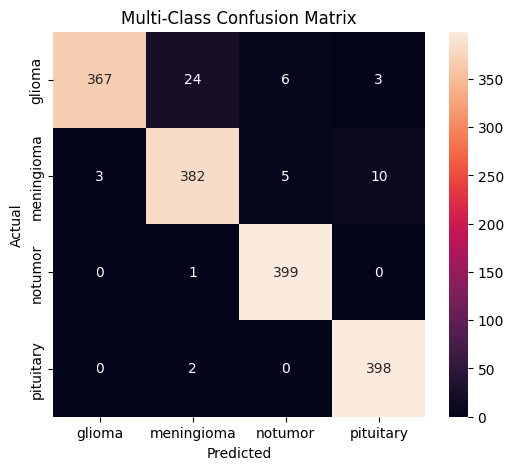

In [ ]:
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class Confusion Matrix")
plt.show()

IMPROPER Binary Model Build

Create Binary Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    classes=['notumor','glioma']  # temporary test
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    classes=['notumor','glioma']
)

Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


Build Binary Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model_binary = VGG16(weights="imagenet",
                          include_top=False,
                          input_shape=(224,224,3))

for layer in base_model_binary.layers:
    layer.trainable = False

binary_model = models.Sequential([
    base_model_binary,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

Improper Class Names

In [ ]:
print(train_data.class_indices)

{'notumor': 0, 'glioma': 1}


#Create binary dataset automatically

In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive"
binary_path = "/content/drive/MyDrive/BinaryDataset"

# Create folders
os.makedirs(binary_path + "/Training/tumor", exist_ok=True)
os.makedirs(binary_path + "/Training/notumor", exist_ok=True)
os.makedirs(binary_path + "/Testing/tumor", exist_ok=True)
os.makedirs(binary_path + "/Testing/notumor", exist_ok=True)

# Merge tumor classes
tumor_classes = ["glioma","meningioma","pituitary"]

for cls in tumor_classes:
    src_train = base_path + "/Training/" + cls
    dst_train = binary_path + "/Training/tumor"
    for file in os.listdir(src_train):
        shutil.copy(os.path.join(src_train,file), dst_train)

    src_test = base_path + "/Testing/" + cls
    dst_test = binary_path + "/Testing/tumor"
    for file in os.listdir(src_test):
        shutil.copy(os.path.join(src_test,file), dst_test)

# Copy notumor
shutil.copytree(base_path + "/Training/notumor",
                binary_path + "/Training/notumor",
                dirs_exist_ok=True)

shutil.copytree(base_path + "/Testing/notumor",
                binary_path + "/Testing/notumor",
                dirs_exist_ok=True)

print("Binary dataset created successfully")

Binary dataset created successfully


In [ ]:
train_path = "/content/drive/MyDrive/BinaryDataset/Training"
test_path = "/content/drive/MyDrive/BinaryDataset/Testing"

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5430 images belonging to 2 classes.


Proper Class Names

In [ ]:
print(train_data.class_indices)

{'notumor': 0, 'tumor': 1}


Build Binary Model (VGG16 Transfer Learning)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model_binary = VGG16(weights="imagenet",
                          include_top=False,
                          input_shape=(224,224,3))

for layer in base_model_binary.layers:
    layer.trainable = False

binary_model = models.Sequential([
    base_model_binary,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

print("Binary model built successfully")

Binary model built successfully


Compile + Train Binary Model (Proper Setup)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

binary_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "binary_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_binary = binary_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8650 - loss: 0.6935

170/170 ━━━━━━━━━━━━━━━━━━━━ 55s 297ms/step - accuracy: 0.8654 - loss: 0.6910 - val_accuracy: 0.9337 - val_loss: 0.1603
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9752 - loss: 0.0784

170/170 ━━━━━━━━━━━━━━━━━━━━ 38s 221ms/step - accuracy: 0.9751 - loss: 0.0784 - val_accuracy: 0.9413 - val_loss: 0.1327
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 37s 215ms/step - accuracy: 0.9734 - loss: 0.0757 - val_accuracy: 0.9375 - val_loss: 0.1780
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9847 - loss: 0.0573

170/170 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step - accuracy: 0.9847 - loss: 0.0573 - val_accuracy: 0.9525 - val_loss: 0.1188
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 36s 211ms/step - accuracy: 0.9819 - loss: 0.0540 - val_accuracy: 0.9413 - val_loss: 0.1692
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 37s 215ms/step - accuracy: 0.9842 - loss: 0.0507 - val_accuracy: 0.9438 - val_loss: 0.1891
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 36s 211ms/step - accuracy: 0.9829 - loss: 0.0551 - val_accuracy: 0.9488 - val_loss: 0.1676


WASTE Binary Confusion Matrix

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step


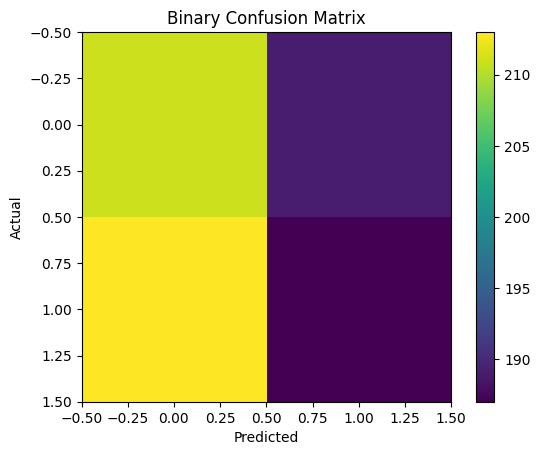

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
binary_model = load_model("binary_model.h5")

pred = binary_model.predict(test_data)
pred_classes = (pred > 0.5).astype(int).reshape(-1)

true_classes = test_data.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step


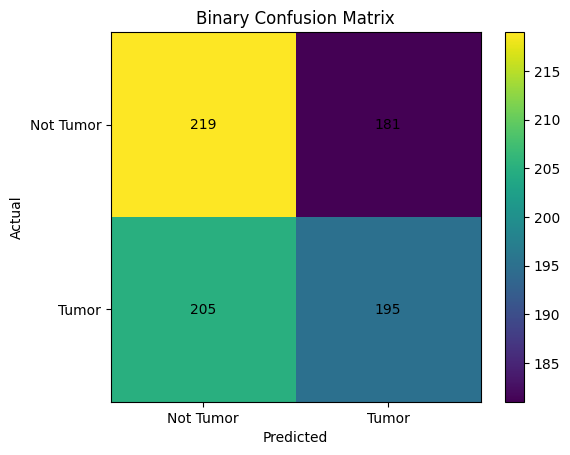

DATA RESET

In [ ]:
test_data.reset()

In [ ]:
test_data.reset()

pred = binary_model.predict(test_data)
pred_classes = (pred > 0.5).astype(int).reshape(-1)
true_classes = test_data.classes

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step


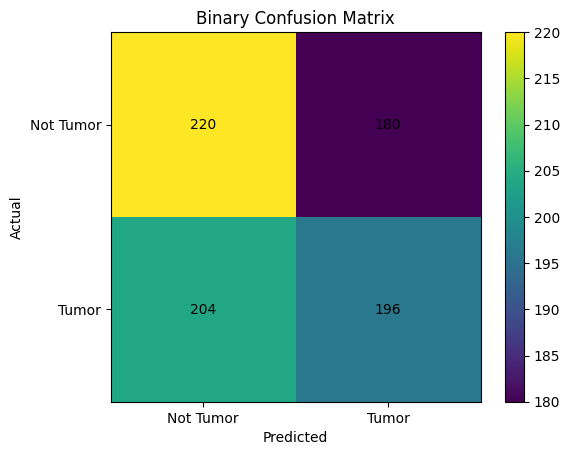

Confusion Matrix:
 [[220 180]
 [204 196]]


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
test_data.reset()

# Predict
pred = binary_model.predict(test_data)
pred_classes = (pred > 0.5).astype(int).reshape(-1)
true_classes = test_data.classes

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Binary Confusion Matrix")

plt.xticks([0,1], ['Not Tumor','Tumor'])
plt.yticks([0,1], ['Not Tumor','Tumor'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("Confusion Matrix:\n", cm)

FINAL FIX

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 1600 images belonging to 2 classes.


In [ ]:
test_data.reset()

pred = binary_model.predict(test_data)
pred_classes = (pred > 0.5).astype(int).reshape(-1)
true_classes = test_data.classes

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step


CONFUSION MATRIX FOR BINARY MODEL

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step
Total test images: 1600
Confusion Matrix:
 [[ 393    7]
 [  43 1157]]
Accuracy: 0.96875


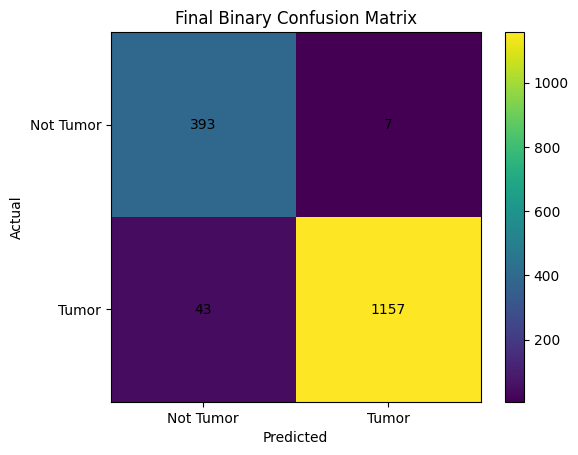

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

test_data.reset()

pred = binary_model.predict(test_data)
pred_classes = (pred > 0.5).astype(int).reshape(-1)
true_classes = test_data.classes

print("Total test images:", len(true_classes))

cm = confusion_matrix(true_classes, pred_classes)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(true_classes, pred_classes)
print("Accuracy:", accuracy)

plt.figure()
plt.imshow(cm)
plt.title("Final Binary Confusion Matrix")
plt.xticks([0,1], ['Not Tumor','Tumor'])
plt.yticks([0,1], ['Not Tumor','Tumor'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

Layer name check

In [ ]:
for layer in binary_model.layers[0].layers:
    print(layer.name)

input_layer_6
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


Grad-CAM Code

In [ ]:
binary_model.predict(np.zeros((1,224,224,3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[0.3174822]], dtype=float32)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# Force model build
binary_model.predict(np.zeros((1,224,224,3)))

# Select one image
img_path = test_data.filepaths[0]

# Load image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Get base VGG model
base_model = binary_model.layers[0]

# Get last conv layer
last_conv_layer = base_model.get_layer("block5_conv3")

# Create Grad model correctly
grad_model = tf.keras.Model(
    inputs=binary_model.input,
    outputs=[last_conv_layer.output, binary_model.output]
)

# Compute gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[0]

grads = tape.gradient(loss, conv_outputs)

# Global average pooling
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Resize heatmap
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Original image
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224,224))

# Overlay
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

# Show result
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m136419716170864\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.        , 0.16078432, 0.3882353 ],\n         [0.08235294, 0.26666668, 0.4862745 ],\n         [0.08235294, 0.25882354, 0.4745098 ],\n         ...,\n         [0.01960784, 0.20392157, 0.36862746],\n         [0.01960784, 0.20392157, 0.36862746],\n         [0.01960784, 0.20392157, 0.36862746]],\n\n        [[0.04705882, 0.21568628, 0.42352942],\n         [0.03921569, 0.2       , 0.40392157],\n         [0.01176471, 0.16862746, 0.36078432],\n         ...,\n         [0.02352941, 0.20392157, 0.39607844],\n         [0.03137255, 0.2       , 0.4       ],\n         [0.02352941, 0.20392157, 0.39607844]],\n\n        [[0.09803922, 0.21960784, 0.39215687],\n         [0.        , 0.11372549, 0.27450982],\n         [0.1254902 , 0.24313726, 0.39215687],\n         ...,\n         [0.02745098, 0.1882353 , 0.4392157 ],\n         [0.03137255, 0.184